In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv("encoded_car_data (1).csv")
data = pd.get_dummies(data, drop_first=True)


In [3]:
X = data.drop('price', axis=1)
y = data['price']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

In [6]:
results = {}

In [7]:
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2)),
        ('regressor', model)
    ])
    
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = {'MSE': mse, 'R2 Score': r2}

C:\ProgramData\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.056e+07, tolerance: 9.781e+05
  model = cd_fast.enet_coordinate_descent(


In [8]:
print("Name:POPURI SAHITHYA")
print("Reg. No:212225240106")

Name:POPURI SAHITHYA
Reg. No:212225240106


In [9]:
for model_name, metrics in results.items():
    print(f"{model_name} - MSE: {metrics['MSE']:.2f}, R2 Score: {metrics['R2 Score']:.2f}")

Ridge - MSE: 10247965.52, R2 Score: 0.87
Lasso - MSE: 37640214.98, R2 Score: 0.52
ElasticNet - MSE: 8715017.38, R2 Score: 0.89


In [10]:
results_df = pd.DataFrame(results).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

In [11]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

(array([0, 1, 2]),
 [Text(0, 0, 'Ridge'), Text(1, 0, 'Lasso'), Text(2, 0, 'ElasticNet')])

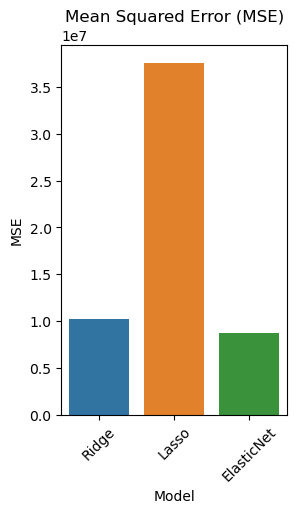

In [12]:
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df)
plt.title('Mean Squared Error (MSE)')
plt.xticks(rotation=45)

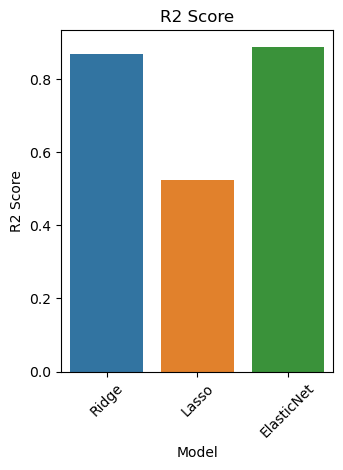

In [13]:
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R2 Score', data=results_df)
plt.title('R2 Score')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()